## Emigration from Denmark Last Year


Revisiting an old post, looking into foreigners leaving Denmark

Who is leaving and where are they going?

In [42]:
# Importing my libraries
import pandas as pd
import folium
import numpy as np
import matplotlib.pyplot as plt
import squarify

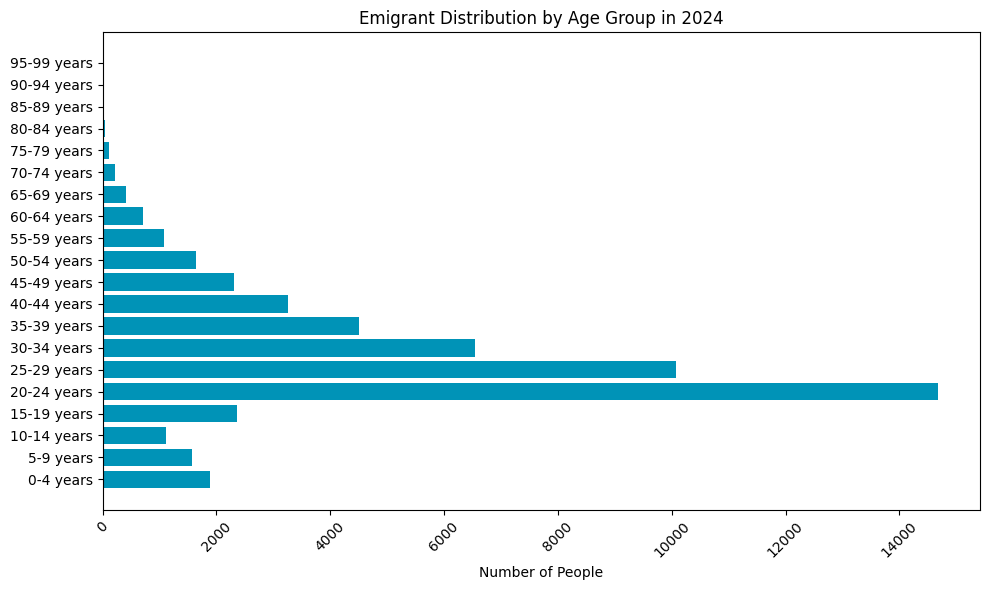

In [43]:
# Data from UDVAN on statbank.dk

df_age = pd.read_csv('ages2024.csv', header=None, encoding='ISO-8859-1')
df_age.columns = ['Citizenship', 'Age Bracket', 'Emigrant Count']
df_age = df_age.drop('Citizenship', axis=1)

# Ensure 'Emigrant Count' is numeric, and coerce any non-numeric values to NaN
df_age['Emigrant Count'] = pd.to_numeric(df_age['Emigrant Count'], errors='coerce')

# Drop rows with a 0 or NaN 'Emigrant Count'
df_age = df_age[df_age['Emigrant Count'].notna() & (df_age['Emigrant Count'] != 0)]

categories = df_age['Age Bracket']
values = df_age['Emigrant Count']

# Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#0093B7']  

# Create a horizontal bar chart
ax.barh(categories, values, color=colors)

# Add labels and title
ax.set_xlabel('Number of People')
ax.set_title('Emigrant Distribution by Age Group in 2024')
ax.xaxis.set_visible(True)
ax.tick_params("x", rotation=45)

# Add values on the bars for clarity
#for i, v in enumerate(values):
#    ax.text(v + 1000, i, str(v), color='black', va='center')
# Remove the borders (spines)
#for spine in ax.spines.values():
#    spine.set_visible(False)

# Save the chart as a PNG file
plt.savefig('foreign_emigration_distribution_2024.png', bbox_inches='tight')
# Show the chart
plt.tight_layout()
plt.show()


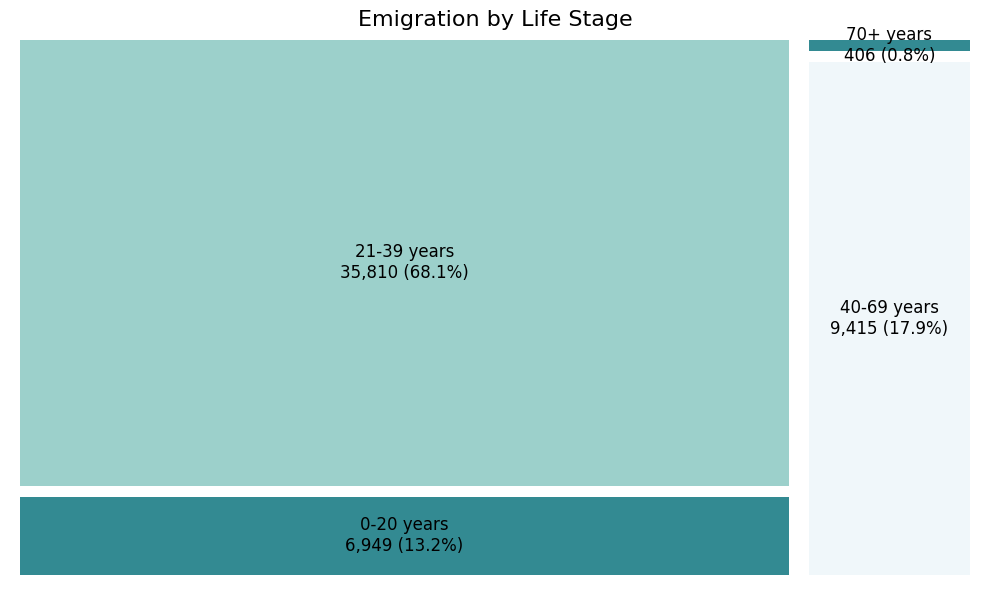

In [44]:
# Group data into the requested age ranges
grouped_data = {"0-20 years": 0, "21-39 years": 0, "40-69 years": 0, "70+ years": 0}

for index, row in df_age.iterrows():
    age_range = row['Age Bracket']
    count = row['Emigrant Count']
    
    # Extract the lower bound of the age range
    if age_range == "110 years +":
        lower_bound = 110
    else:
        lower_bound = int(age_range.split("-")[0])
    
    # Categorize based on age groups
    if lower_bound <= 19:  # 0-19 covers the 0-20 years range
        grouped_data["0-20 years"] += count
    elif lower_bound <= 39:  # 20-39 covers the 21-39 years range
        grouped_data["21-39 years"] += count
    elif lower_bound <= 69:  # 40-69 covers the 40-69 years range
        grouped_data["40-69 years"] += count
    else:  # 70+ years
        grouped_data["70+ years"] += count

# Calculate total
total = sum(grouped_data.values())

# Convert to DataFrame for easier handling
df = pd.DataFrame(list(grouped_data.items()), columns=['Age Group', 'Count'])
df['Percentage'] = (df['Count'] / total * 100).round(1)
df['Label'] = df.apply(lambda x: f"{x['Age Group']}\n{x['Count']:,} ({x['Percentage']}%)", axis=1)

# Create figure
plt.figure(figsize=(10, 6))

# Create color map with shades of teal
teal_shades = ['#006d77', '#83c5be', '#edf6f9']  # Different shades of teal

# Create treemap
squarify.plot(
    sizes=df['Count'],
    label=df['Label'],
    color=teal_shades,
    alpha=0.8,
    pad=0.02,
    text_kwargs={'fontsize': 12}
)

plt.axis('off')
plt.title('Emigration by Life Stage', fontsize=16)
plt.tight_layout()
plt.savefig('emigration_lifestage_treemap.png', dpi=300, bbox_inches='tight')
plt.show()

Looking at the change in emigration between 2023 and 2024, 9% more under 20s stayed but 6% fewer working age adults stayed.

This could be that fewer Ukrainian families returned last year.


In [45]:
#source UDVAN because it has foreign/Denmark as an option so you don't have to aggregate all the citizenships. 

destinations_df = pd.read_csv('destinations2024.csv', header=None, encoding='ISO-8859-1')
destinations_df.columns = ['Citizenship', 'Destination Country', 'Emigrant Count']
destinations_df = destinations_df.drop('Citizenship', axis=1)
# Ensure 'Emigrant Count' is numeric, and coerce any non-numeric values to NaN
destinations_df['Emigrant Count'] = pd.to_numeric(destinations_df['Emigrant Count'], errors='coerce')

# Drop rows with a 0 or NaN 'Emigrant Count'
destinations_df = destinations_df[destinations_df['Emigrant Count'].notna() & (destinations_df['Emigrant Count'] != 0)]

# Sort by 'Emigrant Count' in descending order
destinations_df = destinations_df.sort_values(by='Emigrant Count', ascending=False)

# Reset index
destinations_df = destinations_df.reset_index(drop=True)

# Select the top 15 rows
top_15 = destinations_df.head(15)

top_15.head(15)


,Destination Country,Emigrant Count
0,Not stated,11223
1,USA,3800
2,Romania,3621
3,Poland,3024
4,Germany,3001
5,Ukraine,2363
6,Sweden,1767
7,Norway,1638
8,Spain,1510
9,Italy,1376


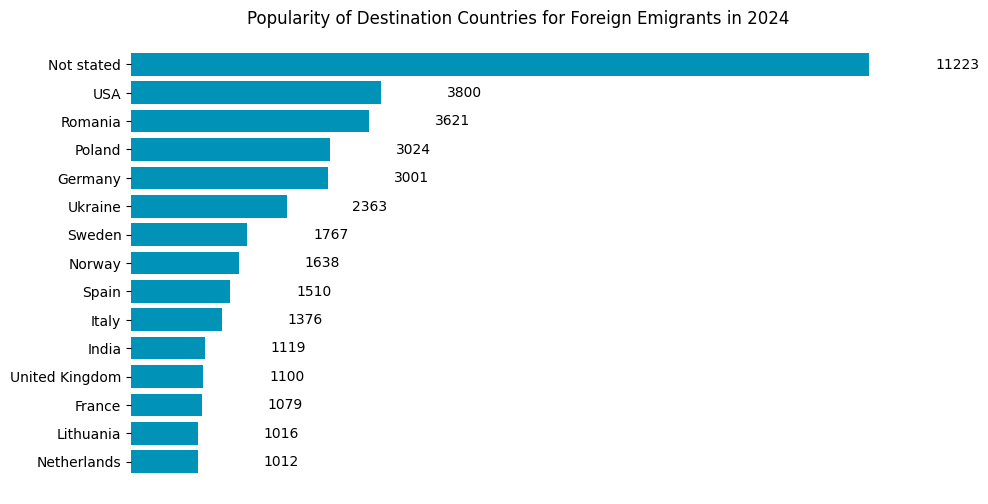

In [46]:
# Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#0092B7']  

categories=top_15['Destination Country']
values=top_15['Emigrant Count']

# Create a bar chart
ax.barh(categories, values, color=colors)

# Invert the y-axis to have the largest bar at the top
plt.gca().invert_yaxis()

# Add labels and title
ax.set_xlabel('Destination')
ax.set_title('Popularity of Destination Countries for Foreign Emigrants in 2024')
# Remove x-axis labels
ax.xaxis.set_visible(False)

# Add values on the bars for clarity
for i, v in enumerate(values):
    ax.text(v + 1000, i, str(v), color='black', va='center')
# Remove the borders (spines)
for spine in ax.spines.values():
    spine.set_visible(False)

# Save the chart as a PNG file
plt.savefig('destinations2024.png', bbox_inches='tight')
# Show the chart

plt.show()


I am curious about the "not stated" category, if it is hiding a very popular destination for example. 

#2024
1.	USA	3800 ⬆️ (and increased by 7% since last year)
2.	Romania	3621 ⬆️ (and increased by 23% since last year)
3.	Poland	3024 ⬆️ (and increased by 23% since last year)
4.	Germany	3001
5.	Ukraine	2363 ⬇️  (decreased by 43% since last year)
6.	Sweden	1767 
7.	Norway	1638 
8.	Spain	1510 
9.	Italy	1376 
10.	India	1119 ⬆️
11.	United Kingdom	1100 ⬇️
12.	France	1079 ⬆️
13.	Lithuania	1016 ⬇️
14.	Netherlands	1012

In [47]:
# Source: VAN2AAR on https://statbank.dk/

emigration_2024_df = pd.read_csv('emigration 2024.csv', header=None, encoding='ISO-8859-1')
emigration_2024_df.columns = ['Citizenship', 'Destination Country', 'Emigrant Count']
emigration_2024_df = emigration_2024_df[emigration_2024_df['Emigrant Count'] != 0]
emigration_2024_df = emigration_2024_df[emigration_2024_df['Destination Country'].str.lower() != 'not stated']
emigration_2024_df = emigration_2024_df[emigration_2024_df['Citizenship'].str.lower() != 'not stated']
emigration_2024_df = emigration_2024_df[emigration_2024_df['Citizenship'].str.lower() != 'stateless']
# Drop rows where the 'Citizenship' is the same as the 'Destination Country'
emigration_2024_df = emigration_2024_df[emigration_2024_df['Citizenship'].str.lower() != emigration_2024_df['Destination Country'].str.lower()]


# Reset the index to avoid gaps after dropping rows
emigration_2024_df = emigration_2024_df.reset_index(drop=True)


So the million dollar question is, how many people are "going home"? For those who are going to start again in another country, which countries are popular?

In [48]:
# Group by destination country and sum the emigrant count
destination_ranking_df = emigration_2024_df.groupby('Destination Country')['Emigrant Count'].sum().reset_index()

# Sort by emigrant count in descending order (highest emigration first)
destination_ranking_df = destination_ranking_df.sort_values(by='Emigrant Count', ascending=False)

destination_ranking_df = destination_ranking_df.reset_index(drop=True)

# If you want to save it to a CSV file
#destination_ranking.to_csv('destination_ranking_2024.csv', index=False)
destination_ranking_df.head(15)

,Destination Country,Emigrant Count
0,Germany,906
1,Sweden,668
2,Spain,605
3,USA,596
4,United Kingdom,498
5,Netherlands,429
6,Norway,331
7,Argentina,296
8,France,288
9,Switzerland,287


Another question is: which nationalities are serial expats?

In [49]:
# Group by citizenship and sum the emigrant count
citizenship_ranking = emigration_2024_df.groupby('Citizenship')['Emigrant Count'].sum().reset_index()

# Sort by emigrant count in descending order (highest emigration first)
citizenship_ranking = citizenship_ranking.sort_values(by='Emigrant Count', ascending=False)

citizenship_ranking = citizenship_ranking.reset_index(drop=True)

citizenship_ranking.head(10)

,Citizenship,Emigrant Count
0,Italy,828
1,Ukraine,595
2,Germany,452
3,Romania,383
4,India,313
5,Spain,286
6,Poland,247
7,China,243
8,Sweden,241
9,France,241


In [50]:
# Path to the GeoJSON file for country boundaries
geojson_url = 'https://raw.githubusercontent.com/python-visualization/folium/master/examples/data/world-countries.json'

# Create a mapping of country names to align them with GeoJSON names
country_name_mapping = {
    'USA': 'United States of America',
    'UK': 'United Kingdom',
    'Russia': 'Russian Federation',
    # Add other mappings as needed...
}

# Apply the mapping 
destination_ranking_df['Destination Country'] = destination_ranking_df['Destination Country'].replace(country_name_mapping)

# Initialize the Folium map centered on Denmark
m = folium.Map(location=[56.26392, 9.501785], zoom_start=1)
mean = np.mean(destination_ranking_df['Emigrant Count'])
std_dev = np.std(destination_ranking_df['Emigrant Count'])
# Define threshold scale based on standard deviations
threshold_scale = [
    0,  # Minimum threshold
    max(1, mean - std_dev),  # At least 1 emigrant, avoid negative or too small values
    mean,  # Mean threshold
    mean + std_dev,  # 1 standard deviation above the mean
    mean + 2 * std_dev,  # 2 standard deviations above the mean
    destination_ranking_df['Emigrant Count'].max()  # Max value from the data
]

# Ensure that threshold values are strictly increasing
threshold_scale = sorted(list(set(threshold_scale)))

# Add Choropleth layer for countries, using Emigrant Count to define the color
folium.Choropleth(
    geo_data=geojson_url,
    name='choropleth',
    data=destination_ranking_df,
    columns=['Destination Country', 'Emigrant Count'],
    key_on='feature.properties.name',  # Match country names in GeoJSON
    fill_color='YlGnBu',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Emigrant Count',
    nan_fill_opacity=0,  # Ensure countries not in the data remain unchanged
    threshold_scale=threshold_scale,
    #threshold_scale=[0, 100, 400, 600, 700, 800],  
).add_to(m)

# Add layer control to toggle
folium.LayerControl().add_to(m)

# Save the map

#m.save('colored_countries_map_2024.html')
m

# Looking at Region Midtjylland
## Source: VAN2AAR on https://statbank.dk/
Finding out the destinations and citizenships of "serial expats" from Midtjylland

In [10]:
midt_df = pd.read_csv('midt2024.csv', header=None, encoding='ISO-8859-1')
midt_df.columns = ['Region', 'Citizenship', 'Destination Country', 'Emigrant Count']
midt_df = midt_df.drop('Region', axis=1)
midt_df = midt_df[midt_df['Emigrant Count'] != 0]
midt_df = midt_df[midt_df['Destination Country'].str.lower() != 'not stated']
midt_df = midt_df[midt_df['Citizenship'].str.lower() != 'not stated']
midt_df = midt_df[midt_df['Citizenship'].str.lower() != 'stateless']
# Drop rows where the 'Citizenship' is the same as the 'Destination Country'
midt_df = midt_df[midt_df['Citizenship'].str.lower() != midt_df['Destination Country'].str.lower()]

# Reset the index to avoid gaps after dropping rows
midt_df = midt_df.reset_index(drop=True)

midt_df.head()
# Group by destination country and sum the emigrant count
midt_destination_ranking = midt_df.groupby('Destination Country')['Emigrant Count'].sum().reset_index()


In [11]:
# Group by citizenship and sum the emigrant count
midt_citizenship_ranking = midt_df.groupby('Citizenship')['Emigrant Count'].sum().reset_index()

# Sort by emigrant count in descending order (highest emigration first)
midt_citizenship_ranking = midt_citizenship_ranking.sort_values(by='Emigrant Count', ascending=False)

midt_citizenship_ranking = midt_citizenship_ranking.reset_index(drop=True)

midt_citizenship_ranking.head(10)

,Citizenship,Emigrant Count
0,Ukraine,137
1,Italy,108
2,Romania,105
3,Syria,67
4,Germany,50
5,Sweden,47
6,Lithuania,46
7,China,44
8,Spain,41
9,Poland,41


In [12]:
# Group by destination country and sum the emigrant count
midt_destination_ranking = midt_df.groupby('Destination Country')['Emigrant Count'].sum().reset_index()

# Sort by emigrant count in descending order (highest emigration first)
midt_destination_ranking = midt_destination_ranking.sort_values(by='Emigrant Count', ascending=False)

midt_destination_ranking = midt_destination_ranking.reset_index(drop=True)

midt_destination_ranking.head(15)

,Destination Country,Emigrant Count
0,Germany,216
1,United Kingdom,106
2,Netherlands,86
3,Spain,83
4,USA,59
5,Poland,48
6,Norway,46
7,Moldova,44
8,Sweden,43
9,Argentina,40


In [13]:
# Apply the mapping to the data
midt_destination_ranking['Destination Country'] = midt_destination_ranking['Destination Country'].replace(country_name_mapping)

# Initialize the Folium map centered on Denmark
m = folium.Map(location=[56.26392, 9.501785], zoom_start=1)
mean = np.mean(midt_destination_ranking['Emigrant Count'])
std_dev = np.std(midt_destination_ranking['Emigrant Count'])
# Define threshold scale based on standard deviations
threshold_scale = [
    0,  # Minimum threshold
    max(1, mean - std_dev),  # At least 1 emigrant, avoid negative or too small values
    mean,  # Mean threshold
    mean + std_dev,  # 1 standard deviation above the mean
    mean + 2 * std_dev,  # 2 standard deviations above the mean
    midt_destination_ranking['Emigrant Count'].max()  # Max value from the data
]

# Ensure that threshold values are strictly increasing
threshold_scale = sorted(list(set(threshold_scale)))

# Add Choropleth layer for countries, using Emigrant Count to define the color
folium.Choropleth(
    geo_data=geojson_url,
    name='choropleth',
    data=midt_destination_ranking,
    columns=['Destination Country', 'Emigrant Count'],
    key_on='feature.properties.name',  # Match country names in GeoJSON
    fill_color='YlGnBu',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Emigrant Count',
    nan_fill_opacity=0,  # Ensure countries not in the data remain unchanged
    threshold_scale=threshold_scale,
    #threshold_scale=[0, 100, 400, 600, 700, 800],  
).add_to(m)

# Add layer control to toggle
folium.LayerControl().add_to(m)

# Save the map

#m.save('midt_colored_countries_map_2024.html')
m

# Looking at Aarhus
## Source: VAN2AAR on https://statbank.dk/
Finding out the destinations and citizenships of "serial expats" from Aarhus

In [14]:
aarhus_df = pd.read_csv('aarhus2024.csv', header=None, encoding='ISO-8859-1')
aarhus_df.columns = ['City', 'Citizenship', 'Destination Country', 'Emigrant Count']
aarhus_df = aarhus_df.drop('City', axis=1)
aarhus_df = aarhus_df[aarhus_df['Emigrant Count'] != 0]
aarhus_df = aarhus_df[aarhus_df['Destination Country'].str.lower() != 'not stated']
aarhus_df = aarhus_df[aarhus_df['Citizenship'].str.lower() != 'not stated']
aarhus_df = aarhus_df[aarhus_df['Citizenship'].str.lower() != 'stateless']






In [15]:
aarhus_citizen = aarhus_df.drop('Destination Country', axis=1)
# Sort the ranking
aarhus_citizen = aarhus_citizen.sort_values(by='Emigrant Count', ascending=False)
# Reset the index to avoid gaps after dropping rows
aarhus_citizen = aarhus_citizen.reset_index(drop=True)

aarhus_citizen.head(5)

,Citizenship,Emigrant Count
0,Germany,231
1,Norway,209
2,China,102
3,Poland,100
4,Romania,97


2023 	Citizenship	Emigrant Count
0	Norway	202
1	Germany	194
2	China	101
3	Italy	100
4	Poland	97


2024	Citizenship	Emigrant Count
Germany	
Norway	
China	
Poland	
Romania	

In [16]:

#Make a dataframe where people go back to their home country
aarhus_home_df = aarhus_df[aarhus_df['Citizenship'].str.lower() == aarhus_df['Destination Country'].str.lower()]
# Sort the ranking
aarhus_home_df = aarhus_home_df.sort_values(by='Emigrant Count', ascending=False)
# Reset the index to avoid gaps after dropping rows
aarhus_home_df = aarhus_home_df.reset_index(drop=True)

# Drop rows where the 'Citizenship' is the same as the 'Destination Country'
aarhus_df = aarhus_df[aarhus_df['Citizenship'].str.lower() != aarhus_df['Destination Country'].str.lower()]

# Reset the index to avoid gaps after dropping rows
aarhus_df = aarhus_df.reset_index(drop=True)


# Group by destination country and sum the emigrant count
aarhus_destination_ranking = aarhus_df.groupby('Destination Country')['Emigrant Count'].sum().reset_index()

In [17]:
aarhus_home_df.head(20)

,Citizenship,Destination Country,Emigrant Count
0,Germany,Germany,231
1,Norway,Norway,209
2,China,China,102
3,Poland,Poland,100
4,Romania,Romania,97
5,Spain,Spain,92
6,Ukraine,Ukraine,89
7,Italy,Italy,87
8,France,France,81
9,Netherlands,Netherlands,80



1 Germany ⬆️
2 Norway ⬇️
3 China	
4 Poland ⬆️	
5 Romania *️⃣	


2023
1	Norway
2	Germany
3	China
4	Italy
5	Poland

2023	
1	Italy	71
2	India	45
3	Germany	45
4	Poland	27
5	Chile	21

2024	
	Italy	
	China	
	Germany	
	Spain	
	Ukraine	

In [18]:
# Sort by emigrant count in descending order (highest emigration first)
aarhus_destination_ranking = aarhus_destination_ranking.sort_values(by='Emigrant Count', ascending=False)

aarhus_destination_ranking = aarhus_destination_ranking.reset_index(drop=True)

# If you want to save it to a CSV file
#aarhus_destination_ranking.to_csv('aarhus_destination_ranking.csv', index=False)
aarhus_destination_ranking.head(15)

,Destination Country,Emigrant Count
0,Germany,104
1,United Kingdom,72
2,Netherlands,63
3,Spain,60
4,Argentina,26
5,Switzerland,25
6,Sweden,25
7,France,24
8,Norway,22
9,Italy,22


2023
1	Germany	91
2	Netherlands	48
3	United Kingdom	40
4	USA	35
5	Spain	34

2024
Germany	
United Kingdom	⬆️
Netherlands	⬇️
Spain	⬆️
Argentina	*️⃣

In [19]:
# Group by citizenship and sum the emigrant count
aarhus_citizenship_ranking = aarhus_df.groupby('Citizenship')['Emigrant Count'].sum().reset_index()

# Sort by emigrant count in descending order (highest emigration first)
aarhus_citizenship_ranking = aarhus_citizenship_ranking.sort_values(by='Emigrant Count', ascending=False)

aarhus_citizenship_ranking = aarhus_citizenship_ranking.reset_index(drop=True)

aarhus_citizenship_ranking.head(10)

,Citizenship,Emigrant Count
0,Italy,93
1,China,35
2,Germany,29
3,Spain,28
4,Ukraine,27
5,Romania,26
6,India,24
7,Sweden,22
8,Poland,19
9,Hungary,17


In [20]:

# Apply the name mapping
aarhus_destination_ranking['Destination Country'] = aarhus_destination_ranking['Destination Country'].replace(country_name_mapping)

# Initialize the Folium map centered on Denmark
m = folium.Map(location=[56.26392, 9.501785], zoom_start=1)
mean = np.mean(midt_destination_ranking['Emigrant Count'])
std_dev = np.std(midt_destination_ranking['Emigrant Count'])
# Define threshold scale based on standard deviations
threshold_scale = [
    0,  # Minimum threshold
    max(1, mean - std_dev),  # At least 1 emigrant, avoid negative or too small values
    mean,  # Mean threshold
    mean + std_dev,  # 1 standard deviation above the mean
    mean + 2 * std_dev,  # 2 standard deviations above the mean
    aarhus_destination_ranking['Emigrant Count'].max()  # Max value from the data
]

# Ensure that threshold values are strictly increasing
threshold_scale = sorted(list(set(threshold_scale)))

# Add Choropleth layer for countries, using Emigrant Count to define the color
folium.Choropleth(
    geo_data=geojson_url,
    name='choropleth',
    data=aarhus_destination_ranking,
    columns=['Destination Country', 'Emigrant Count'],
    key_on='feature.properties.name',  # Match country names in GeoJSON
    fill_color='YlGnBu',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Emigrant Count',
    nan_fill_opacity=0,  # Ensure countries not in the data remain unchanged
    threshold_scale=threshold_scale,
    #threshold_scale=[0, 100, 400, 600, 700, 800],  
).add_to(m)

# Add layer control to toggle
folium.LayerControl().add_to(m)

# Save the map

m.save('aarhus_colored_countries_map_2024.html')
m

In [21]:

# Load the data
df_aarhus_age = pd.read_csv('aarhus_age_24.csv', header=None, encoding='ISO-8859-1')
df_aarhus_age.columns = ['City', 'Age', 'Citizenship', 'Emigrant Count']
df_aarhus_age = df_aarhus_age.drop('City', axis=1)

# Clean the Age column by removing "years"/"year" and converting to integer
def clean_age(age_str):
    # Convert to string to ensure string methods work
    age_str = str(age_str)
    
    # Remove "years" or "year" and any extra spaces
    age_str = age_str.replace('years', '').replace('year', '').strip()
    
    # Handle any "+" symbol for ranges like "110+"
    if '+' in age_str:
        age_str = age_str.replace('+', '').strip()
    
    # Convert to integer
    try:
        return int(age_str)
    except ValueError:
        # If conversion fails, return original value
        print(f"Could not convert {age_str} to integer")
        return age_str

# Apply the cleaning function to the Age column
df_aarhus_age['Age'] = df_aarhus_age['Age'].apply(clean_age)

# Now the Age column should be an integer and will sort correctly

df_aarhus_age_summed = df_aarhus_age.groupby('Age')['Emigrant Count'].sum().reset_index()
# Drop ages with 0 emigrants
df_aarhus_age_summed = df_aarhus_age_summed[df_aarhus_age_summed['Emigrant Count'] > 0]

print(df_aarhus_age_summed)

    Age  Emigrant Count
0     0              16
1     1              24
2     2              23
3     3              22
4     4              18
..  ...             ...
78   78               1
79   79               1
80   80               1
83   83               1
92   92               1

[82 rows x 2 columns]


In [22]:
# Group into age ranges
grouped_data = {"0-20 years": 0, "21-39 years": 0, "40-69 years": 0, "70+ years": 0}

# Iterate through rows of the DataFrame
for index, row in df_aarhus_age_summed.iterrows():
    age = row['Age']
    count = row['Emigrant Count']
    
    # Convert age to integer if it's not already
    try:
        age_num = int(age)
    except ValueError:
        # Handle cases like "110 years +" if they exist
        if "+" in str(age):
            age_num = int(str(age).split()[0])
        else:
            continue  # Skip if we can't parse the age
    
    # Categorize based on age groups
    if age_num <= 20:
        grouped_data["0-20 years"] += count
    elif age_num <= 39:
        grouped_data["21-39 years"] += count
    elif age_num <= 69:
        grouped_data["40-69 years"] += count
    else:  # 70+ years
        grouped_data["70+ years"] += count

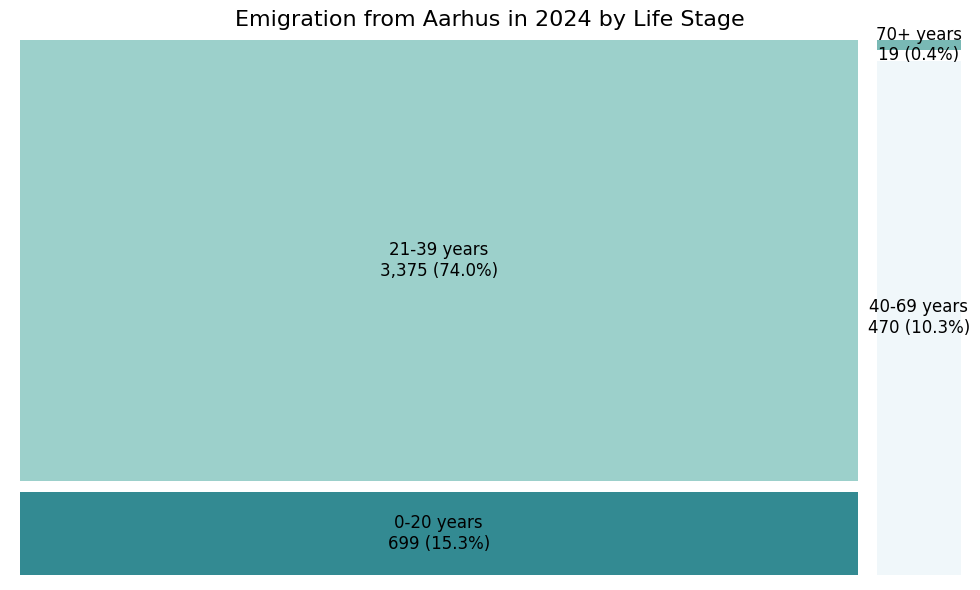

In [23]:
# Calculate total, ensure it's not zero
total = sum(grouped_data.values())
if total == 0:
    print("Warning: Total count is zero!")
    total = 1  # Prevent division by zero

# Convert to DataFrame for easier handling
df = pd.DataFrame(list(grouped_data.items()), columns=['Age Group', 'Count'])

# Filter out zero counts before plotting
df_non_zero = df[df['Count'] > 0].copy()

if df_non_zero.empty:
    print("No data to plot! All counts are zero.")
else:
    # Calculate percentages only for non-zero rows
    df_non_zero['Percentage'] = (df_non_zero['Count'] / total * 100).round(1)
    df_non_zero['Label'] = df_non_zero.apply(lambda x: f"{x['Age Group']}\n{x['Count']:,} ({x['Percentage']}%)", axis=1)
    
    # Create figure
    plt.figure(figsize=(10, 6))
    
    # Create color map with shades of teal - adjust colors to match number of groups
    teal_shades = ['#006d77', '#83c5be', '#edf6f9', '#57a8a3'][:len(df_non_zero)]
    
    # Create treemap
    squarify.plot(
        sizes=df_non_zero['Count'],
        label=df_non_zero['Label'],
        color=teal_shades,
        alpha=0.8,
        pad=0.02,
        text_kwargs={'fontsize': 12}
    )
    
    plt.axis('off')
    plt.title('Emigration from Aarhus in 2024 by Life Stage', fontsize=16)
    plt.tight_layout()
    plt.savefig('emigration_lifestage_treemap_aarhus.png', dpi=300, bbox_inches='tight')
    plt.show()

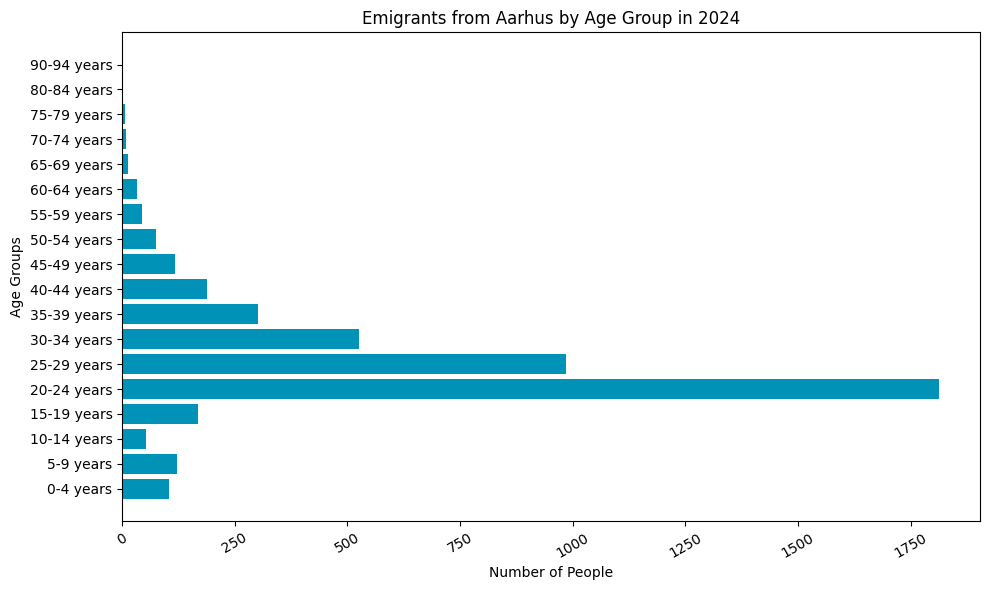

In [30]:
# Data from UDVAN on statbank.dk

df_age = pd.read_csv('aarhus_age_buckets_24.csv', header=None, encoding='ISO-8859-1')
df_age.columns = ['Citizenship', 'Age Bracket', 'Emigrant Count']
df_age = df_age.drop('Citizenship', axis=1)

# Ensure 'Emigrant Count' is numeric, and coerce any non-numeric values to NaN
df_age['Emigrant Count'] = pd.to_numeric(df_age['Emigrant Count'], errors='coerce')

# Drop rows with a 0 or NaN 'Emigrant Count'
df_age = df_age[df_age['Emigrant Count'].notna() & (df_age['Emigrant Count'] != 0)]

categories = df_age['Age Bracket']
values = df_age['Emigrant Count']

# Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#0093B7']  

# Create a horizontal bar chart
ax.barh(categories, values, color=colors)

# Add labels and title
ax.set_xlabel('Number of People')
ax.set_ylabel('Age Groups')
ax.set_title('Emigrants from Aarhus by Age Group in 2024')
ax.xaxis.set_visible(True)
ax.tick_params("x", rotation=30)

# Add values on the bars for clarity
#for i, v in enumerate(values):
#    ax.text(v + 1000, i, str(v), color='black', va='center')
# Remove the borders (spines)
#for spine in ax.spines.values():
#    spine.set_visible(False)

# Save the chart as a PNG file
plt.savefig('aarhus_age.png', bbox_inches='tight')
# Show the chart
plt.tight_layout()
plt.show()
